In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta 
import numpy as np
import warnings

In [2]:
tickers = ["GOOG", "AAPL", "NVDA", "MSFT"]
df = yf.download(tickers, group_by="Ticker", start="2020-01-01", end="2025-01-01")
df = df.stack(level = 0, future_stack=True)
df = df.reset_index()
df


[*********************100%***********************]  4 of 4 completed


Price,Date,Ticker,Open,High,Low,Close,Volume
0,2020-01-02,GOOG,66.491263,67.809142,66.491263,67.770981,28132000
1,2020-01-02,NVDA,5.934967,5.963802,5.884504,5.963802,237536000
2,2020-01-02,MSFT,150.090202,151.933479,149.664833,151.829498,22622100
3,2020-01-02,AAPL,71.344054,72.394086,71.091184,72.333878,135480400
4,2020-01-03,GOOG,66.803994,68.025229,66.689207,67.438400,23728000
...,...,...,...,...,...,...,...
5027,2024-12-30,AAPL,250.628701,251.890642,249.158101,250.598892,35557500
5028,2024-12-31,GOOG,191.448526,192.249351,188.598356,189.453903,14355200
5029,2024-12-31,NVDA,137.824165,137.864114,133.630431,134.089737,155659200
5030,2024-12-31,MSFT,421.104456,421.727075,415.728232,416.558380,13246500


In [24]:
def download_ohlcv_data(
    tickers: list[str],
    start_date: str,
    end_date: str
) -> pd.DataFrame:

    if not tickers:
        raise ValueError("tickers cannot be empty")

    if not all(isinstance(t, str) for t in tickers):
        raise TypeError("tickers must contain strings")

    if start_date >= end_date:
        raise ValueError(
            "start_date must be before end_date"
        )

    tickers = [ticker.upper() for ticker in tickers]

    df = yf.download(
        tickers,
        group_by="Ticker",
        start=start_date,
        end=end_date
    )

    if df.empty:
        raise ValueError(
            "No data returned from Yahoo Finance"
        )

    df = df.stack(
        level=0,
        future_stack=True
    )

    df = df.reset_index()

    return df

In [27]:
df = download_ohlcv_data(tickers, "2020-01-01", "2025-01-01")
df.head()

[*********************100%***********************]  4 of 4 completed


Price,Date,Ticker,Open,High,Low,Close,Volume
0,2020-01-02,GOOG,66.491263,67.809142,66.491263,67.770981,28132000
1,2020-01-02,MSFT,150.090202,151.933479,149.664833,151.829498,22622100
2,2020-01-02,AAPL,71.344054,72.394086,71.091184,72.333878,135480400
3,2020-01-02,NVDA,5.934967,5.963802,5.884504,5.963802,237536000
4,2020-01-03,GOOG,66.803994,68.025229,66.689207,67.438400,23728000


In [22]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5032 entries, 0 to 5031
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype        
---  ------  --------------  -----        
 0   Date    5032 non-null   datetime64[s]
 1   Ticker  5032 non-null   str          
 2   Open    5032 non-null   float64      
 3   High    5032 non-null   float64      
 4   Low     5032 non-null   float64      
 5   Close   5032 non-null   float64      
 6   Volume  5032 non-null   int64        
dtypes: datetime64[s](1), float64(4), int64(1), str(1)
memory usage: 275.3 KB
None


In [4]:
print(df.describe())

Price                 Date         Open         High          Low  \
count                 5032  5032.000000  5032.000000  5032.000000   
mean   2022-07-01 15:39:46   148.518955   150.166578   146.895891   
min    2020-01-02 00:00:00     4.977163     5.221917     4.494122   
25%    2021-04-01 00:00:00    74.655663    75.415585    73.808627   
50%    2022-06-30 12:00:00   136.874154   138.483023   135.131097   
75%    2023-10-02 00:00:00   195.292451   197.860184   192.964357   
max    2024-12-31 00:00:00   459.774284   461.103408   457.273604   
std                    NaN   103.298653   104.098088   102.419084   

Price        Close        Volume  
count  5032.000000  5.032000e+03  
mean    148.596521  1.483483e+08  
min       4.885130  6.809800e+06  
25%      74.902237  2.493200e+07  
50%     136.710510  4.806105e+07  
75%     195.446011  1.931070e+08  
max     460.325623  1.543911e+09  
std     103.302653  1.998378e+08  


In [5]:
print(df.head())

Price       Date Ticker        Open        High         Low       Close  \
0     2020-01-02   GOOG   66.491263   67.809142   66.491263   67.770981   
1     2020-01-02   NVDA    5.934967    5.963802    5.884504    5.963802   
2     2020-01-02   MSFT  150.090202  151.933479  149.664833  151.829498   
3     2020-01-02   AAPL   71.344054   72.394086   71.091184   72.333878   
4     2020-01-03   GOOG   66.803994   68.025229   66.689207   67.438400   

Price     Volume  
0       28132000  
1      237536000  
2       22622100  
3      135480400  
4       23728000  


In [6]:
print(df["Ticker"].value_counts())

Ticker
GOOG    1258
NVDA    1258
MSFT    1258
AAPL    1258
Name: count, dtype: int64


array([[<Axes: title={'center': 'Open'}>,
        <Axes: title={'center': 'High'}>],
       [<Axes: title={'center': 'Low'}>,
        <Axes: title={'center': 'Close'}>]], dtype=object)

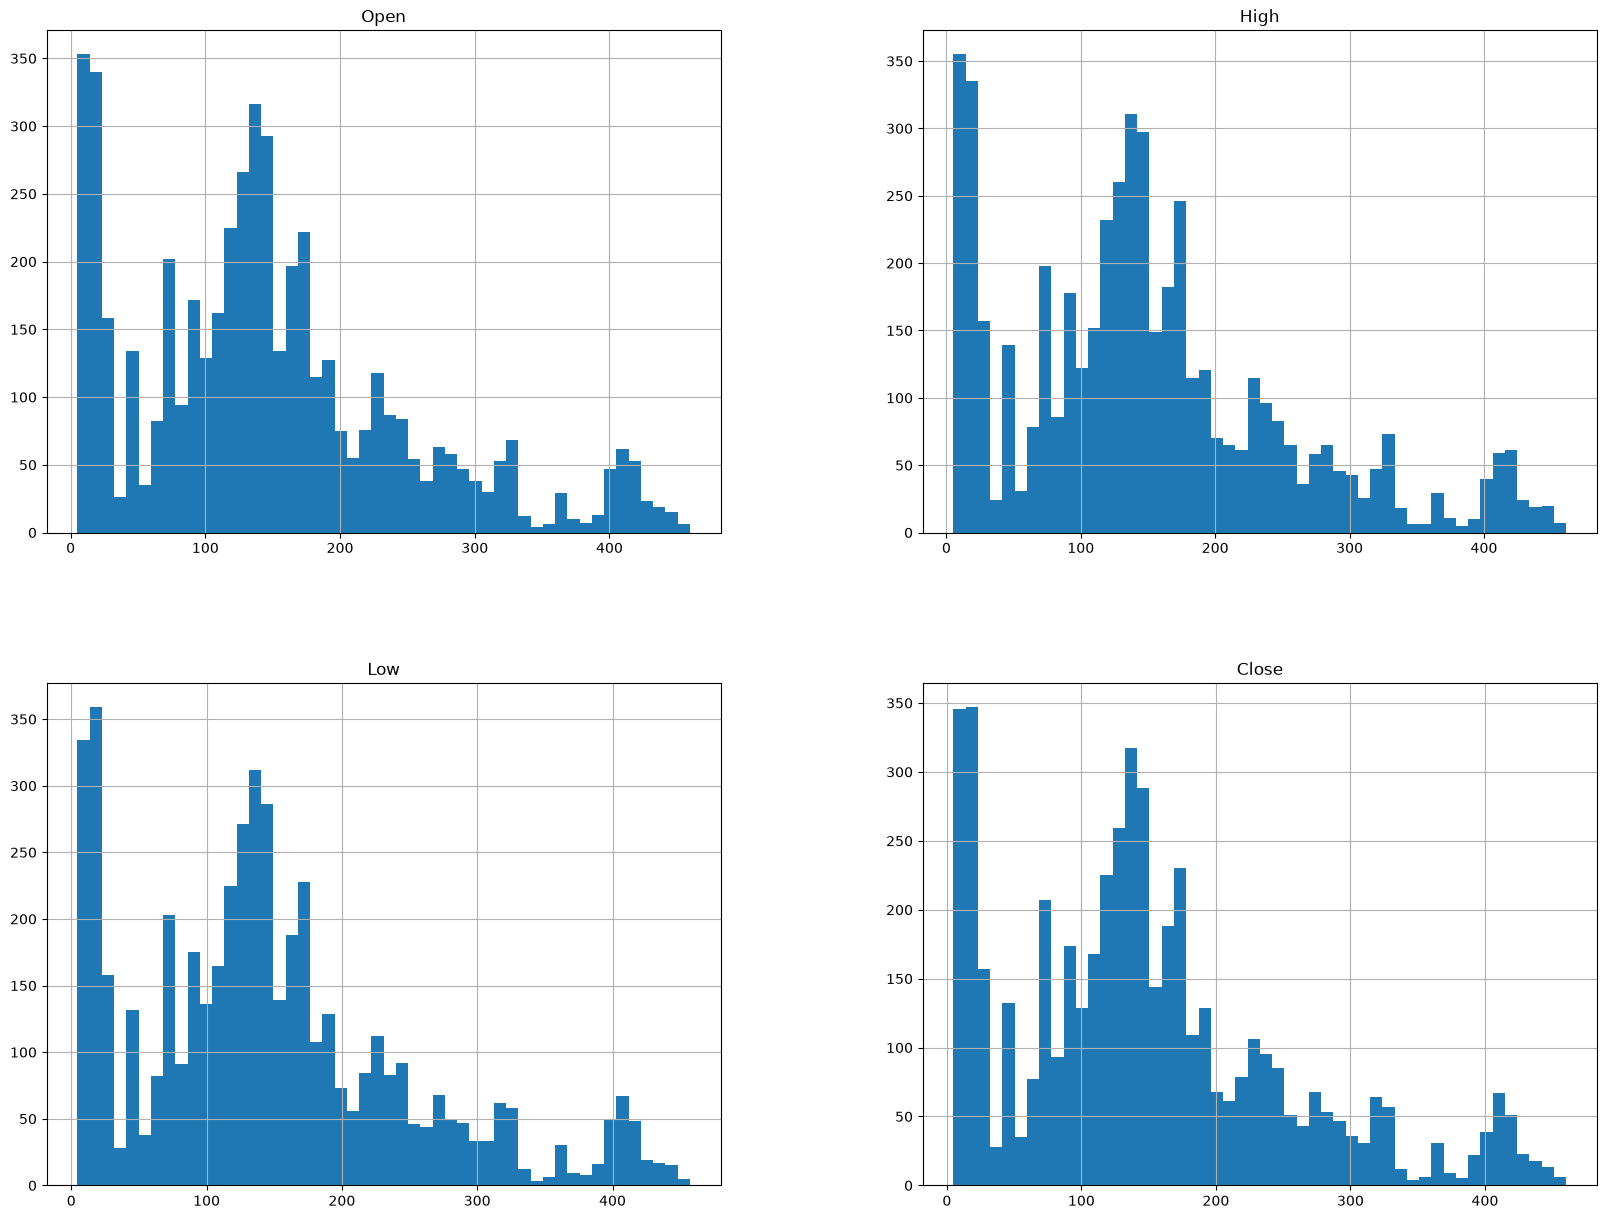

In [7]:
df.iloc[:, [1,2,3,4,5]].hist(bins=50, figsize=(20,15))

In [8]:
print(df.corr(numeric_only = True))

Price       Open      High       Low     Close    Volume
Price                                                   
Open    1.000000  0.999881  0.999865  0.999711 -0.602122
High    0.999881  1.000000  0.999838  0.999861 -0.601977
Low     0.999865  0.999838  1.000000  0.999878 -0.603223
Close   0.999711  0.999861  0.999878  1.000000 -0.602607
Volume -0.602122 -0.601977 -0.603223 -0.602607  1.000000


In [9]:
df.head()

Price,Date,Ticker,Open,High,Low,Close,Volume
0,2020-01-02,GOOG,66.491263,67.809142,66.491263,67.770981,28132000
1,2020-01-02,NVDA,5.934967,5.963802,5.884504,5.963802,237536000
2,2020-01-02,MSFT,150.090202,151.933479,149.664833,151.829498,22622100
3,2020-01-02,AAPL,71.344054,72.394086,71.091184,72.333878,135480400
4,2020-01-03,GOOG,66.803994,68.025229,66.689207,67.438400,23728000


In [11]:
from financial_forecasting_platform.pipelines.feature_engineering.nodes import feature_engineering, target_variable_engineering
feature_engineered_df = feature_engineering(df)
feature_engineered_df['market_movement'] = target_variable_engineering(df).values
feature_engineered_df['market_movement'].value_counts()
feature_engineered_df.head()

Price,Date,Ticker,Open,High,Low,Close,Volume,return_lag_1,return_lag_5,return_lag_10,...,lower_shadow_pct,volume_pct_change,relative_volume_30,volume_sma_20,return_x_volume,drawdown_30,sharpe_30,day_of_week,month,market_movement
0,2020-01-02,GOOG,66.491263,67.809142,66.491263,67.770981,28132000,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,Thursday,01,0.0
1,2020-01-02,NVDA,5.934967,5.963802,5.884504,5.963802,237536000,NaN,NaN,NaN,...,0.008461,NaN,NaN,NaN,NaN,NaN,NaN,Thursday,01,0.0
2,2020-01-02,MSFT,150.090202,151.933479,149.664833,151.829498,22622100,NaN,NaN,NaN,...,0.002802,NaN,NaN,NaN,NaN,NaN,NaN,Thursday,01,0.0
3,2020-01-02,AAPL,71.344054,72.394086,71.091184,72.333878,135480400,NaN,NaN,NaN,...,0.003496,NaN,NaN,NaN,NaN,NaN,NaN,Thursday,01,0.0
4,2020-01-03,GOOG,66.803994,68.025229,66.689207,67.438400,23728000,-0.004907,NaN,NaN,...,0.001702,-0.156548,NaN,NaN,-7.891472e+06,NaN,NaN,Friday,01,1.0


array([[<Axes: title={'center': 'Date'}>,
        <Axes: title={'center': 'Open'}>,
        <Axes: title={'center': 'High'}>,
        <Axes: title={'center': 'Low'}>,
        <Axes: title={'center': 'Close'}>,
        <Axes: title={'center': 'Volume'}>,
        <Axes: title={'center': 'return_lag_1'}>],
       [<Axes: title={'center': 'return_lag_5'}>,
        <Axes: title={'center': 'return_lag_10'}>,
        <Axes: title={'center': 'return_lag_20'}>,
        <Axes: title={'center': 'log_return_lag_1'}>,
        <Axes: title={'center': 'SMA_5'}>,
        <Axes: title={'center': 'SMA_20'}>,
        <Axes: title={'center': 'SMA_50'}>],
       [<Axes: title={'center': 'ema_12'}>,
        <Axes: title={'center': 'ema_26'}>,
        <Axes: title={'center': 'close_vs_SMA_20'}>,
        <Axes: title={'center': 'rsi_14'}>,
        <Axes: title={'center': 'momentum_5'}>,
        <Axes: title={'center': 'momentum_20'}>,
        <Axes: title={'center': 'momentum_60'}>],
       [<Axes: title={'ce

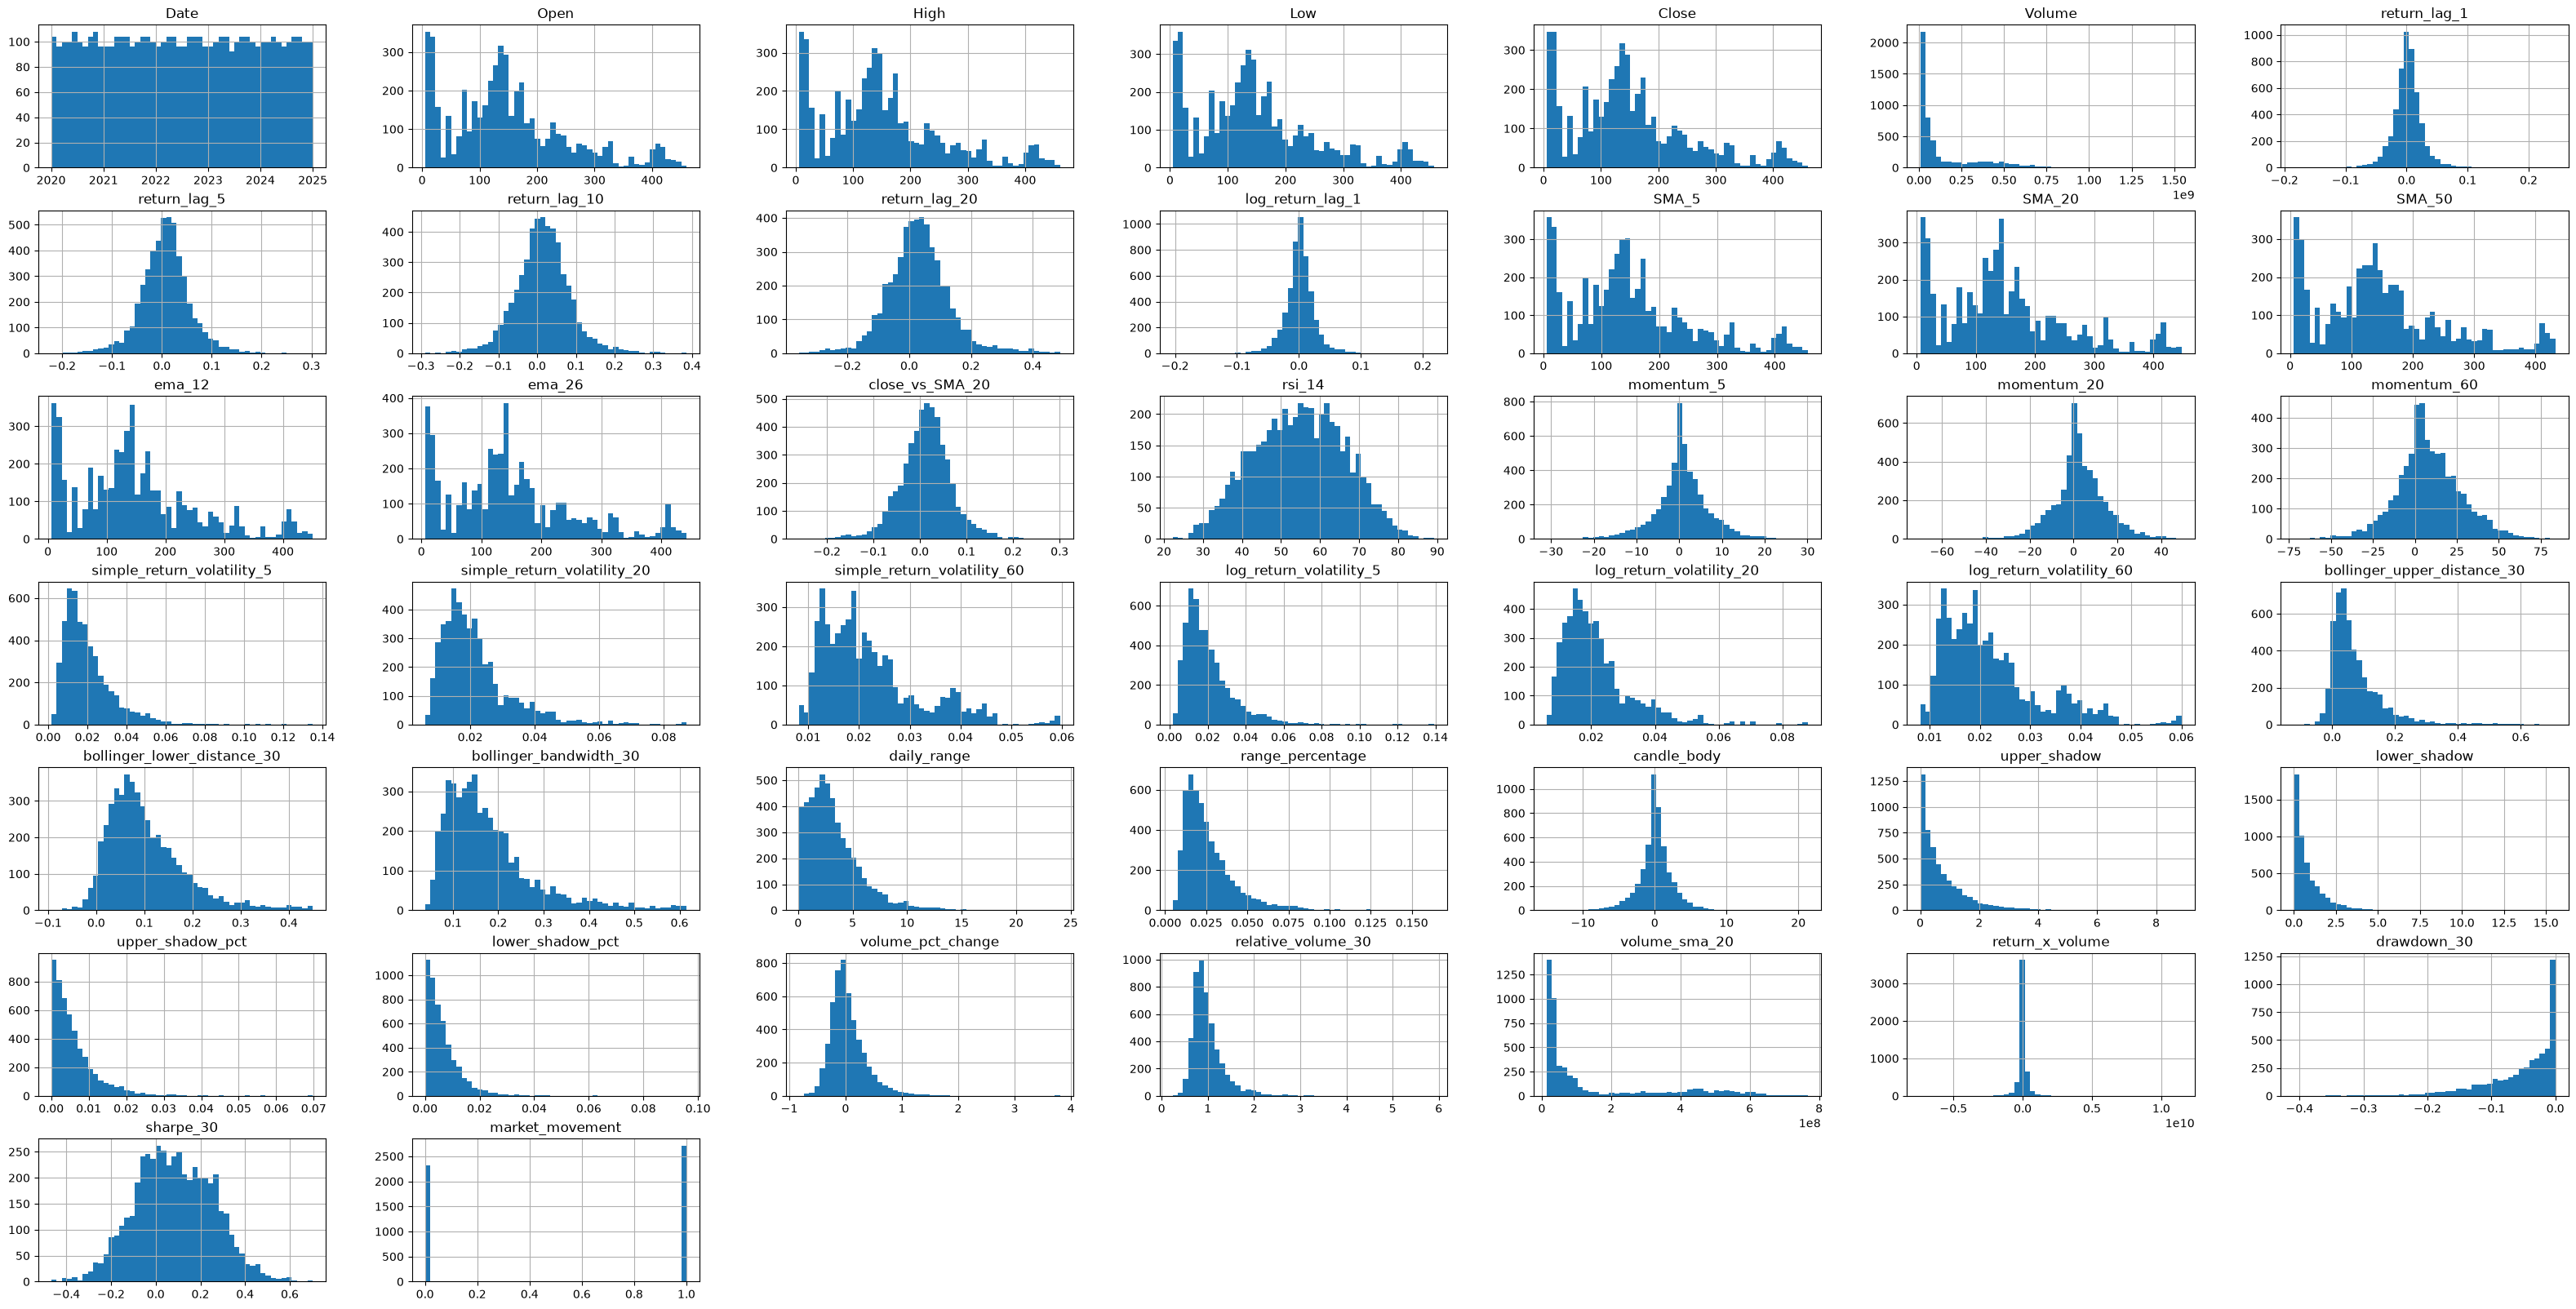

In [12]:
feature_engineered_df.iloc[:].hist(bins=50, figsize=(40,20))

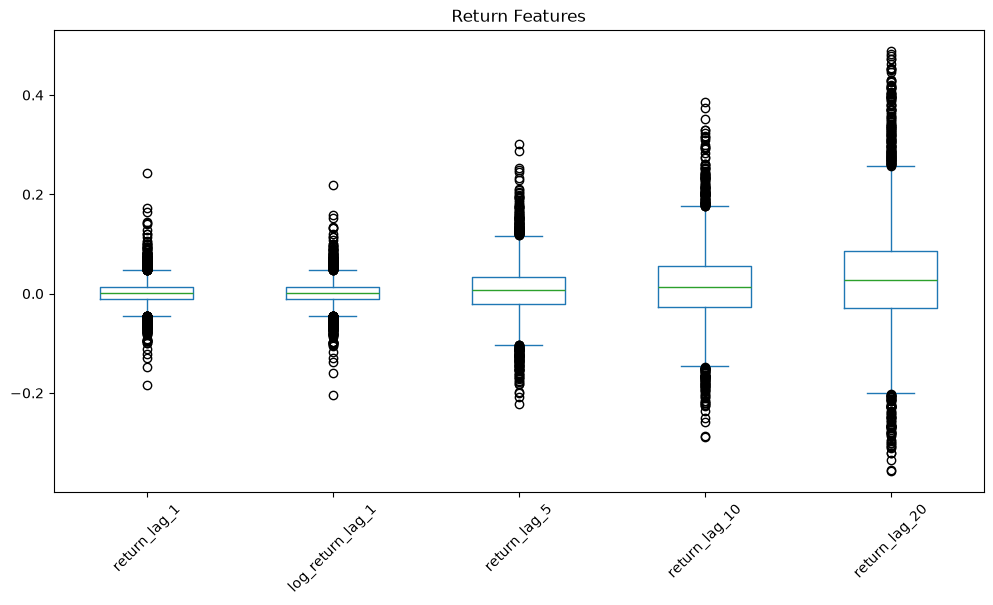

In [13]:
return_features = [
    "return_lag_1",
    "log_return_lag_1",
    "return_lag_5",
    "return_lag_10",
    "return_lag_20"
]

feature_engineered_df[return_features].plot.box(figsize=(12,6))
plt.title("Return Features")
plt.xticks(rotation=45)
plt.show()


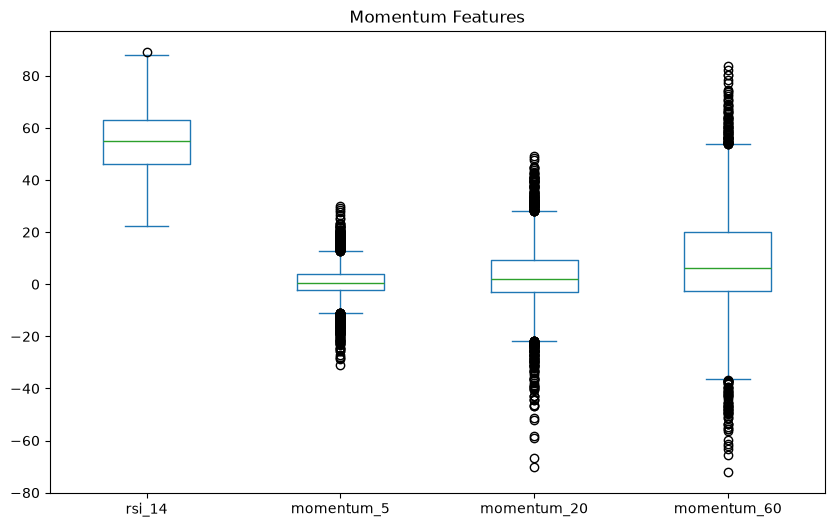

In [15]:
momentum_features = [
    "rsi_14",
    "momentum_5",
    "momentum_20",
    "momentum_60"
]

feature_engineered_df[momentum_features].plot.box(figsize=(10,6))
plt.title("Momentum Features")
plt.show()

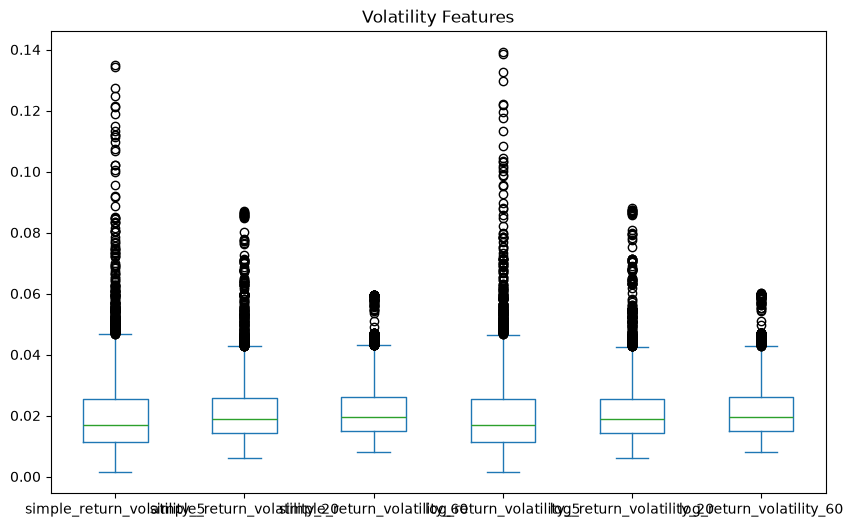

In [16]:
volatility_features = [
    "simple_return_volatility_5",
    "simple_return_volatility_20",
    "simple_return_volatility_60",
    "log_return_volatility_5",
    "log_return_volatility_20",
    "log_return_volatility_60"
]

feature_engineered_df[volatility_features].plot.box(figsize=(10,6))
plt.title("Volatility Features")
plt.show()

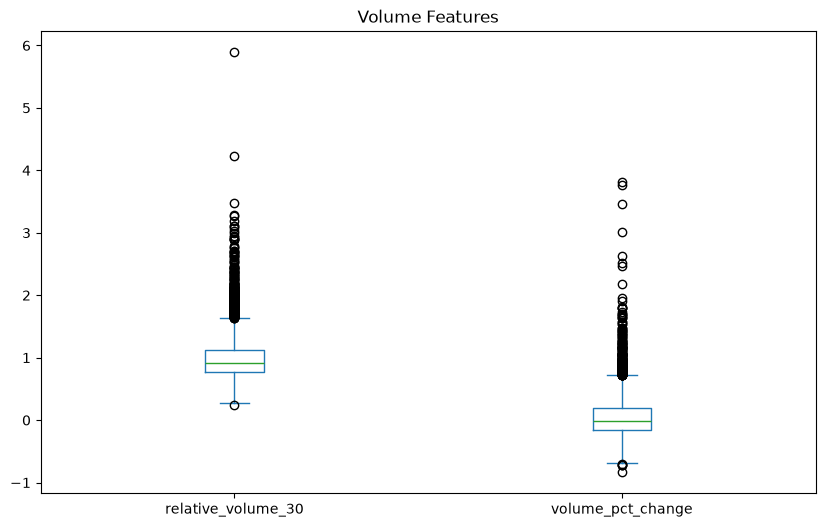

In [17]:
volume_features = [
    "relative_volume_30",
    "volume_pct_change"
]

feature_engineered_df[volume_features].plot.box(figsize=(10,6))
plt.title("Volume Features")
plt.show()

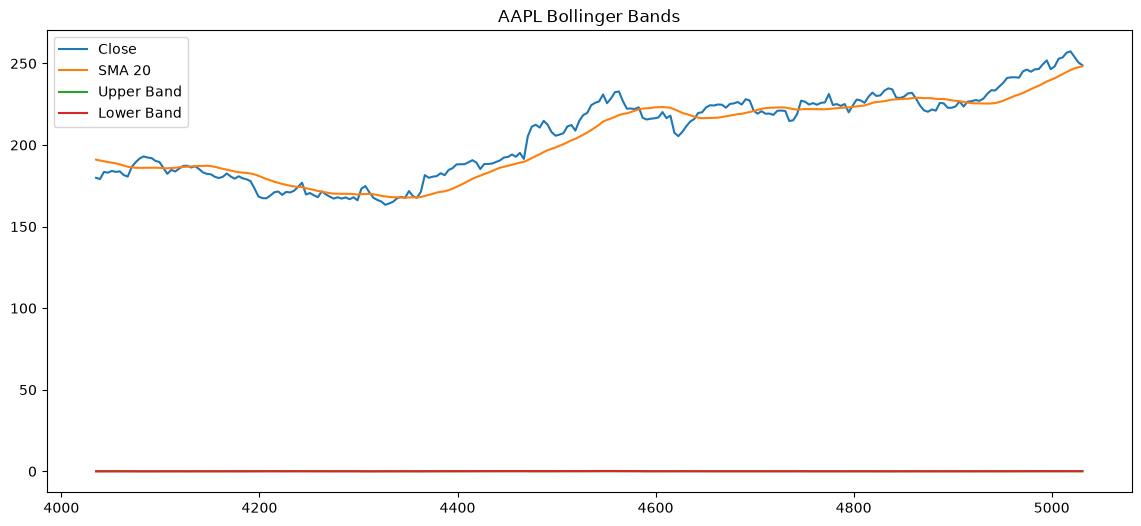

In [18]:
ticker = "AAPL"

plot_df = feature_engineered_df[feature_engineered_df["Ticker"] == ticker].tail(250)

plt.figure(figsize=(14,6))

plt.plot(plot_df.index, plot_df["Close"], label="Close")
plt.plot(plot_df.index, plot_df["SMA_20"], label="SMA 20")
plt.plot(plot_df.index, plot_df["bollinger_upper_distance_30"], label="Upper Band")
plt.plot(plot_df.index, plot_df["bollinger_lower_distance_30"], label="Lower Band")

plt.fill_between(
    plot_df.index,
    plot_df["bollinger_lower_distance_30"],
    plot_df["bollinger_upper_distance_30"],
    alpha=0.2
)

plt.title(f"{ticker} Bollinger Bands")
plt.legend()
plt.show()

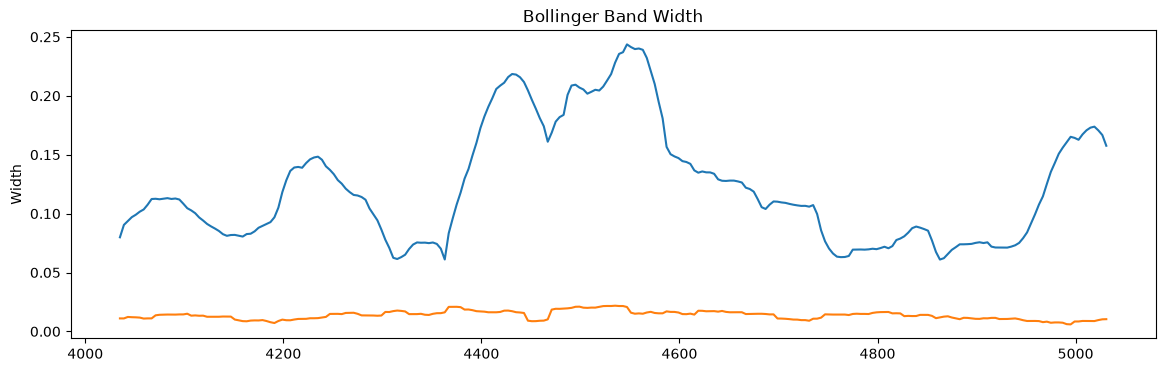

In [19]:
plt.figure(figsize=(14,4))

plt.plot(plot_df.index, plot_df["bollinger_bandwidth_30"])
plt.plot(plot_df.index, plot_df["simple_return_volatility_20"])

plt.title("Bollinger Band Width")
plt.ylabel("Width")
plt.show()